# Time-series data

In [368]:
import pandas as pd
import seaborn as sns

- When you work with time-series data, you’ll often want to index the data based on time periods like weeks, months, or quarters.
- To do that, you first generate the time periods that you want.
- Then, you reindex the data based on those periods.
- Once that’s done, it’s easy to summarize or plot the data based on those time periods.

## How to generate time periods

### Use the date_range() method to generate the time periods that you want to use.
- This sets the range for the year 2020
- Frequency "MS" represents "Month Start"
- This makes the dates, on the first of each month, e.g. 3/1/20
- Experiment with 'B', 'W-MON', '12h'

In [369]:
pd.date_range('01/01/2020','12/31/2020', freq='MS')

DatetimeIndex(['2020-01-01', '2020-02-01', '2020-03-01', '2020-04-01',
               '2020-05-01', '2020-06-01', '2020-07-01', '2020-08-01',
               '2020-09-01', '2020-10-01', '2020-11-01', '2020-12-01'],
              dtype='datetime64[ns]', freq='MS')

#### Every 12 hours for a month

In [370]:
pd.date_range('01/01/2020', '01/31/2020', freq='12h')

DatetimeIndex(['2020-01-01 00:00:00', '2020-01-01 12:00:00',
               '2020-01-02 00:00:00', '2020-01-02 12:00:00',
               '2020-01-03 00:00:00', '2020-01-03 12:00:00',
               '2020-01-04 00:00:00', '2020-01-04 12:00:00',
               '2020-01-05 00:00:00', '2020-01-05 12:00:00',
               '2020-01-06 00:00:00', '2020-01-06 12:00:00',
               '2020-01-07 00:00:00', '2020-01-07 12:00:00',
               '2020-01-08 00:00:00', '2020-01-08 12:00:00',
               '2020-01-09 00:00:00', '2020-01-09 12:00:00',
               '2020-01-10 00:00:00', '2020-01-10 12:00:00',
               '2020-01-11 00:00:00', '2020-01-11 12:00:00',
               '2020-01-12 00:00:00', '2020-01-12 12:00:00',
               '2020-01-13 00:00:00', '2020-01-13 12:00:00',
               '2020-01-14 00:00:00', '2020-01-14 12:00:00',
               '2020-01-15 00:00:00', '2020-01-15 12:00:00',
               '2020-01-16 00:00:00', '2020-01-16 12:00:00',
               '2020-01-

## How to reindex with datetime indexes (Stock Market Data)

### Let's look at the original data
##### Summary
- We are looking at the year 2020
- 252 rows
- 4 columns date, open, high, low, close

### WARNING:  Change this to match the path of your data

In [371]:
# get stock data
stockData = pd.read_csv('../data/AAPL.csv', usecols=['Date','Open','High','Low','Close'], 
                        parse_dates=['Date'])

In [372]:
stockData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253 entries, 0 to 252
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    253 non-null    datetime64[ns]
 1   Open    253 non-null    float64       
 2   High    253 non-null    float64       
 3   Low     253 non-null    float64       
 4   Close   253 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 10.0 KB


In [373]:
print("Index: ", stockData.index)
print("Columns:", stockData.columns)
print("Size: ", stockData.size)
print("Shape: ", stockData.shape)

Index:  RangeIndex(start=0, stop=253, step=1)
Columns: Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='object')
Size:  1265
Shape:  (253, 5)


In [374]:
stockData.head(3)

,Date,Open,High,Low,Close
0,2020-01-02,74.059998,75.150002,73.797501,75.087502
1,2020-01-03,74.287498,75.144997,74.125000,74.357498
2,2020-01-06,73.447502,74.989998,73.187500,74.949997


In [375]:
stockData.tail(3)

,Date,Open,High,Low,Close
250,2020-12-29,138.050003,138.789993,134.339996,134.869995
251,2020-12-30,135.580002,135.990005,133.399994,133.720001
252,2020-12-31,134.080002,134.740005,131.720001,132.690002


### Reindex based on the date range
- We do not want the index to be the generic index.
- We want the row index to the the date

In [376]:
stockData = stockData.set_index('Date')
stockData.head(5)

,Open,High,Low,Close
Date,,,,
2020-01-02,74.059998,75.150002,73.797501,75.087502
2020-01-03,74.287498,75.144997,74.125000,74.357498
2020-01-06,73.447502,74.989998,73.187500,74.949997
2020-01-07,74.959999,75.224998,74.370003,74.597504
2020-01-08,74.290001,76.110001,74.290001,75.797501


In [377]:
stockData.tail(5)

,Open,High,Low,Close
Date,,,,
2020-12-24,131.320007,133.460007,131.100006,131.970001
2020-12-28,133.990005,137.339996,133.509995,136.690002
2020-12-29,138.050003,138.789993,134.339996,134.869995
2020-12-30,135.580002,135.990005,133.399994,133.720001
2020-12-31,134.080002,134.740005,131.720001,132.690002


### We can reindex based on just looking at the data on Friday
- We set a new data range
- Then we reindex on the date range ("Fridays")

In [378]:
fridays = pd.date_range('01/01/2020', '12/31/2020', freq='W-FRI')
fridays

DatetimeIndex(['2020-01-03', '2020-01-10', '2020-01-17', '2020-01-24',
               '2020-01-31', '2020-02-07', '2020-02-14', '2020-02-21',
               '2020-02-28', '2020-03-06', '2020-03-13', '2020-03-20',
               '2020-03-27', '2020-04-03', '2020-04-10', '2020-04-17',
               '2020-04-24', '2020-05-01', '2020-05-08', '2020-05-15',
               '2020-05-22', '2020-05-29', '2020-06-05', '2020-06-12',
               '2020-06-19', '2020-06-26', '2020-07-03', '2020-07-10',
               '2020-07-17', '2020-07-24', '2020-07-31', '2020-08-07',
               '2020-08-14', '2020-08-21', '2020-08-28', '2020-09-04',
               '2020-09-11', '2020-09-18', '2020-09-25', '2020-10-02',
               '2020-10-09', '2020-10-16', '2020-10-23', '2020-10-30',
               '2020-11-06', '2020-11-13', '2020-11-20', '2020-11-27',
               '2020-12-04', '2020-12-11', '2020-12-18', '2020-12-25'],
              dtype='datetime64[ns]', freq='W-FRI')

In [379]:
stockData.reindex(fridays).head(5)

,Open,High,Low,Close
2020-01-03,74.287498,75.144997,74.125000,74.357498
2020-01-10,77.650002,78.167503,77.062500,77.582497
2020-01-17,79.067497,79.684998,78.750000,79.682503
2020-01-24,80.062500,80.832497,79.379997,79.577499
2020-01-31,80.232498,80.669998,77.072502,77.377502


## How to reindex with a semi-month index

 - When you reindex and plot the data for a range of dates, you may be surprised to see the number of missing values.
 - Semi-month days often land on weekends because semi-month means the 1st and the 15th of each month. 

In [380]:
semiMonths = pd.date_range('01/01/2020', '12/31/2020', freq='SMS')
semiMonths

DatetimeIndex(['2020-01-01', '2020-01-15', '2020-02-01', '2020-02-15',
               '2020-03-01', '2020-03-15', '2020-04-01', '2020-04-15',
               '2020-05-01', '2020-05-15', '2020-06-01', '2020-06-15',
               '2020-07-01', '2020-07-15', '2020-08-01', '2020-08-15',
               '2020-09-01', '2020-09-15', '2020-10-01', '2020-10-15',
               '2020-11-01', '2020-11-15', '2020-12-01', '2020-12-15'],
              dtype='datetime64[ns]', freq='SMS-15')

In [381]:
stockData.reindex(semiMonths).head()

,Open,High,Low,Close
2020-01-01,NaN,NaN,NaN,NaN
2020-01-15,77.962502,78.875,77.387497,77.834999
2020-02-01,NaN,NaN,NaN,NaN
2020-02-15,NaN,NaN,NaN,NaN
2020-03-01,NaN,NaN,NaN,NaN


<Axes: >

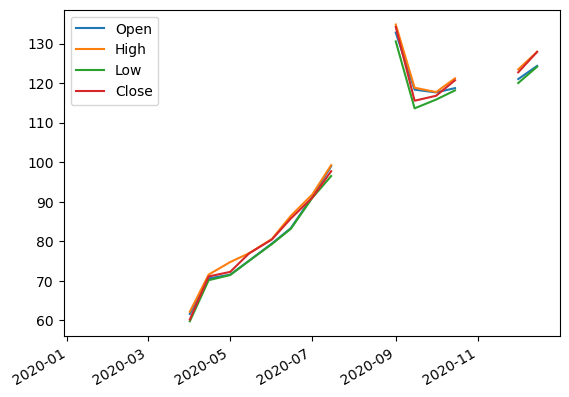

In [382]:
stockData.reindex(semiMonths).plot()

## How a user-defined function can improve a datetime index

### But what if you wanted semi-month data without missing values?
- Use a User Defined function to nudge the original data.
- weekday() returns a number representing the day of the week, starting at 0 on monday
- We nudge Saturday's to the previous Friday. 
- We nudge Sundays to the following Monday. 

In [383]:
import datetime as dt

def adjustDate(date):
    if date.weekday() < 5:
        return date
    elif date.weekday() == 5:
        return date - dt.timedelta(days=1)
    else:
        return date + dt.timedelta(days=1)

### Convert all of the adjusted dates to a series using the function
- There is still a problem with the first date because the preceding date is outside of the data set.
- But notice that the 3/1/20 data was increased to 3/2/20 

In [384]:
semiMonths = pd.date_range('01/01/2020', '12/31/2020', freq='SMS')
semiMonthsAdjusted = semiMonths.to_series().apply(adjustDate)
semiMonthsAdjusted.head()

2020-01-01   2020-01-01
2020-01-15   2020-01-15
2020-02-01   2020-01-31
2020-02-15   2020-02-14
2020-03-01   2020-03-02
Freq: SMS-15, dtype: datetime64[ns]

In [385]:
stockData.reindex(semiMonthsAdjusted).head()

,Open,High,Low,Close
2020-01-01,NaN,NaN,NaN,NaN
2020-01-15,77.962502,78.875000,77.387497,77.834999
2020-01-31,80.232498,80.669998,77.072502,77.377502
2020-02-14,81.184998,81.495003,80.712502,81.237503
2020-03-02,70.570000,75.360001,69.430000,74.702499


## How reindexing with an improved index can improve plots
- The user defined function has drastically improved the plot

##### Original Data

In [386]:
stockData.reindex(semiMonths).head()

,Open,High,Low,Close
2020-01-01,NaN,NaN,NaN,NaN
2020-01-15,77.962502,78.875,77.387497,77.834999
2020-02-01,NaN,NaN,NaN,NaN
2020-02-15,NaN,NaN,NaN,NaN
2020-03-01,NaN,NaN,NaN,NaN


##### New data using the user defined function 

In [387]:
stockData.reindex(semiMonthsAdjusted).head()

,Open,High,Low,Close
2020-01-01,NaN,NaN,NaN,NaN
2020-01-15,77.962502,78.875000,77.387497,77.834999
2020-01-31,80.232498,80.669998,77.072502,77.377502
2020-02-14,81.184998,81.495003,80.712502,81.237503
2020-03-02,70.570000,75.360001,69.430000,74.702499


<Axes: >

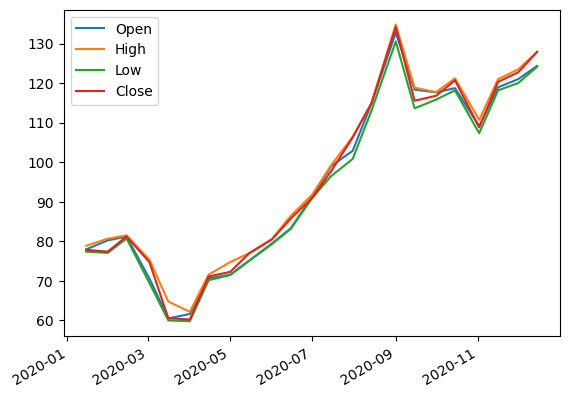

In [388]:
stockData.reindex(semiMonthsAdjusted).plot()

## How to use the resample() method (Forest Fire Data)
- We will go back to the "Aceres Burned" column of the Forest Fires Data
- We have one column acres burned
- We have rows representing every day from 1992 to 2015 (8697 rows)

### Resampling
- Resampling is adjusting the freqency of the data.
- We will look at dataset that samples the data every day of the year over many years
- This produces a lot of data.
- Resampling would involve looking at the data every month.
- This is called "downsampling"

In [389]:
acresBurned = pd.read_pickle('../data/acresBurned.pkl')

### Let's look at the original data

In [390]:
acresBurned.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8697 entries, 1992-01-01 to 2015-12-31
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   acres_burned  8697 non-null   float64
dtypes: float64(1)
memory usage: 135.9 KB


In [391]:
print("Index: ", acresBurned.index)
print("Columns:", acresBurned.columns)
print("Size: ", acresBurned.size)
print("Shape: ", acresBurned.shape)

Index:  DatetimeIndex(['1992-01-01', '1992-01-02', '1992-01-03', '1992-01-04',
               '1992-01-05', '1992-01-06', '1992-01-07', '1992-01-08',
               '1992-01-09', '1992-01-10',
               ...
               '2015-12-20', '2015-12-21', '2015-12-22', '2015-12-23',
               '2015-12-24', '2015-12-25', '2015-12-26', '2015-12-27',
               '2015-12-28', '2015-12-31'],
              dtype='datetime64[ns]', name='discovery_date', length=8697, freq=None)
Columns: Index(['acres_burned'], dtype='object')
Size:  8697
Shape:  (8697, 1)


In [392]:
acresBurned.head(5)

,acres_burned
discovery_date,
1992-01-01,1280.76
1992-01-02,122.50
1992-01-03,526.00
1992-01-04,1150.13
1992-01-05,408.00


In [393]:
acresBurned.tail(5)

,acres_burned
discovery_date,
2015-12-25,25.0
2015-12-26,1861.0
2015-12-27,302.0
2015-12-28,12.0
2015-12-31,20.0


### Resample to only index on Month End ('M'), but sum the data for that month 

In [394]:
acresBurned.resample(rule='M').sum().head(5)

,acres_burned
discovery_date,
1992-01-31,26779.35
1992-02-29,73605.86
1992-03-31,115644.53
1992-04-30,83030.67
1992-05-31,114641.17


<Axes: xlabel='discovery_date'>

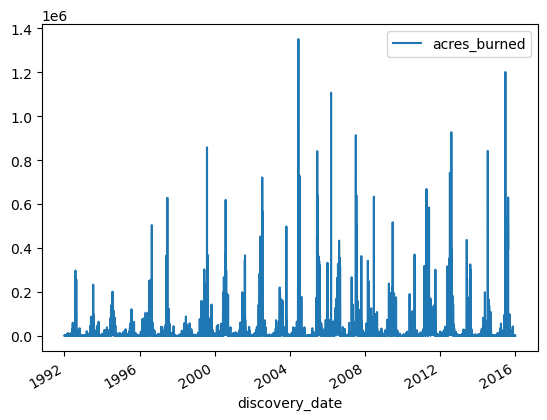

In [395]:
acresBurned.plot()

## How to use the label and closed parameters when you downsample

- label:  Which bin edge will be used as the label, right or left.  The default depends on the rule parameter.
- closed: Which bin edge will be closed, right or left.  The closed edge is included in the aggregated data


In [396]:
acresBurned.head(3)

,acres_burned
discovery_date,
1992-01-01,1280.76
1992-01-02,122.50
1992-01-03,526.00


### Quarter ends for "right" are 3/31, 6/30, 9/30 etc. 
- The right bin edge is used as the index

In [397]:
acresBurned.resample(rule='Q', label='right', closed='right').sum().head()

,acres_burned
discovery_date,
1992-03-31,216029.74
1992-06-30,485118.67
1992-09-30,1293714.71
1992-12-31,129026.79
1993-03-31,141047.95


In [398]:
### Quarter ends for "left" are 12/31, 6/30 etc. 

In [399]:
acresBurned.resample(rule='Q', label='left', closed='left').sum().head()

,acres_burned
discovery_date,
1991-12-31,213086.74
1992-03-31,487341.67
1992-06-30,1290628.71
1992-09-30,132765.79
1992-12-31,139471.71


## How downsampling can improve plots (Stock Data)
##### NOTE:  The stock data does not include data for weekends.  Those rows are missing, but there are no rows with NaN values

In [400]:
stockData.head(5)

,Open,High,Low,Close
Date,,,,
2020-01-02,74.059998,75.150002,73.797501,75.087502
2020-01-03,74.287498,75.144997,74.125000,74.357498
2020-01-06,73.447502,74.989998,73.187500,74.949997
2020-01-07,74.959999,75.224998,74.370003,74.597504
2020-01-08,74.290001,76.110001,74.290001,75.797501


<Axes: xlabel='Date'>

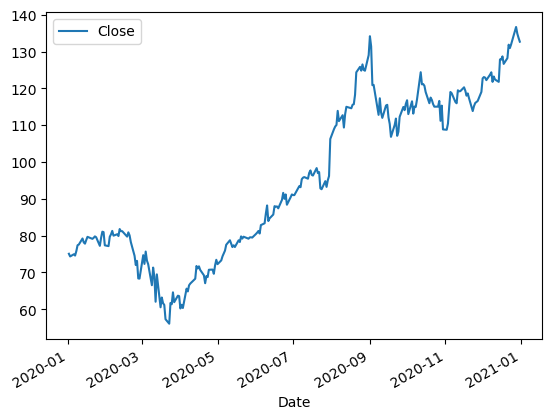

In [401]:
stockData.plot(y='Close')

### Now we resample to weekly

<Axes: xlabel='Date'>

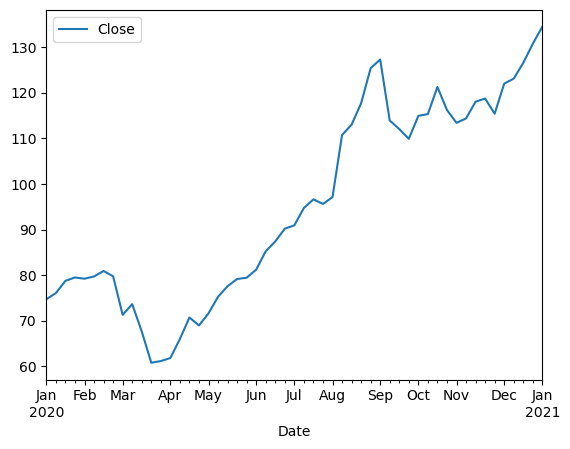

In [402]:
stockData.resample(rule='W').mean().plot(y='Close')

## The concept of rolling windows
- Rolling windows, also known as moving windows, provide another way to smooth the trendlines in noisy data.
- Instead of plotting the actual value for each day, you plot an aggregation of values over a set number of days.

### Resampling
- Changes the frequency of your time series (upsampling or downsampling).
- Groups data into fixed time bins (e.g., monthly, weekly) and aggregates.
- Good for summarizing data at a different temporal resolution.

### Rolling Windows 
- Operates on a moving window over the data.
- Keeps the original frequency of the data.
- Each output value is based on a window of previous (or centered) values.
- Good for smoothing or calculating trends (e.g., moving average, moving sum, rolling std).

#### Without rolling Windows
- Each existing data point for January is plotted.
- There are gaps for the weekends, but those are not NaN values.  They just aren't there.

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


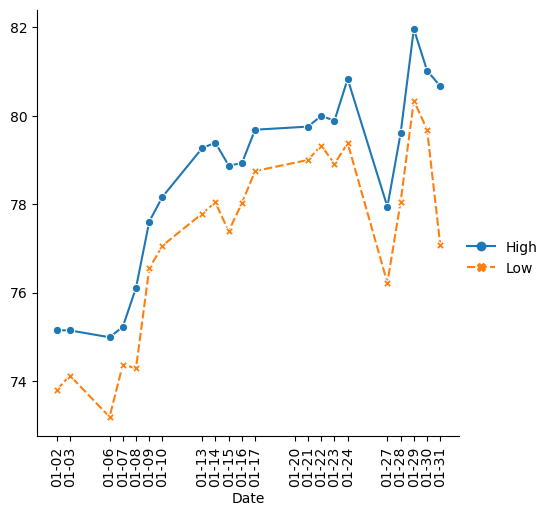

In [403]:
df = stockData[['High','Low']].query('Date <= "01/31/2020"')

g = sns.relplot(data=df, kind='line', markers=True)
for ax in g.axes.flat:
    ax.tick_params('x',labelrotation=90)
    ax.set_xticks(pd.date_range(start='01/02/2020', end='01/31/2020', 
                                freq='B'))
    ax.set_xticklabels(pd.date_range(start='01/02/2020', end='01/31/2020', 
                                     freq='B').strftime('%m-%d'))

#### The highs and lows for the stock data with rolling windows 

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


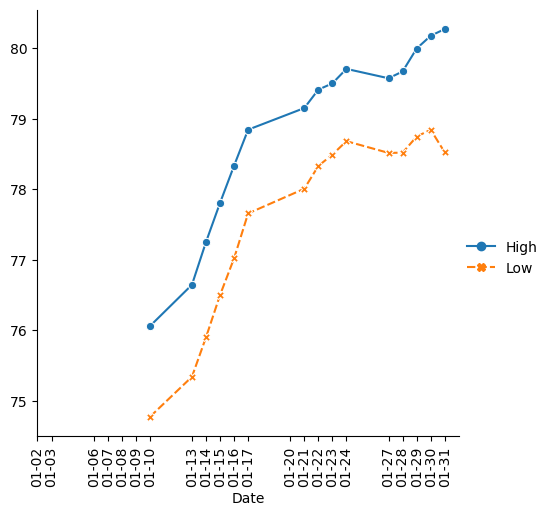

In [404]:
df = stockData[['High','Low']].query('Date <= "01/31/2020"') \
                              .rolling(window=7, min_periods=7).mean()

g = sns.relplot(data=df, kind='line', markers=True)
for ax in g.axes.flat:
    ax.tick_params('x',labelrotation=90)
    ax.set_xticks(pd.date_range(start='01/02/2020', end='01/31/2020', 
                                freq='B'))
    ax.set_xticklabels(pd.date_range(start='01/02/2020', end='01/31/2020', 
                                     freq='B').strftime('%m-%d'))

## How to create rolling windows

- rolling() Creates a moving window (bin) that can be used for performing aggregations.
- window: The size in a nunmber of rows for the window
- min_periods: The minimum number of consecutive values a window value

##### In the first example, the window is 7 but the min_periods parameter is not set.  There must be 7 consecutive non-missing values


In [405]:
df = stockData[['High','Low']]. \
    query('Date <= "01/31/2020"').rolling(window=7).mean()
df.head(8)

,High,Low
Date,,
2020-01-02,NaN,NaN
2020-01-03,NaN,NaN
2020-01-06,NaN,NaN
2020-01-07,NaN,NaN
2020-01-08,NaN,NaN
2020-01-09,NaN,NaN
2020-01-10,76.056428,74.768930
2020-01-13,76.644642,75.338929


In [406]:
##### Setting the min_periods to 1, ensures that the mean will be calculated as long as their is at least one 

In [407]:
df = stockData[['High','Low']]. \
    query('Date <= "01/31/2020"').rolling(window=7, min_periods=1).mean()
df.head(8)

,High,Low
Date,,
2020-01-02,75.150002,73.797501
2020-01-03,75.147500,73.961251
2020-01-06,75.094999,73.703334
2020-01-07,75.127499,73.870001
2020-01-08,75.323999,73.954001
2020-01-09,75.704582,74.386668
2020-01-10,76.056428,74.768930
2020-01-13,76.644642,75.338929


## How to plot rolling window data
- The min_periods is set to 7 to that will be the first rolling average.  

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


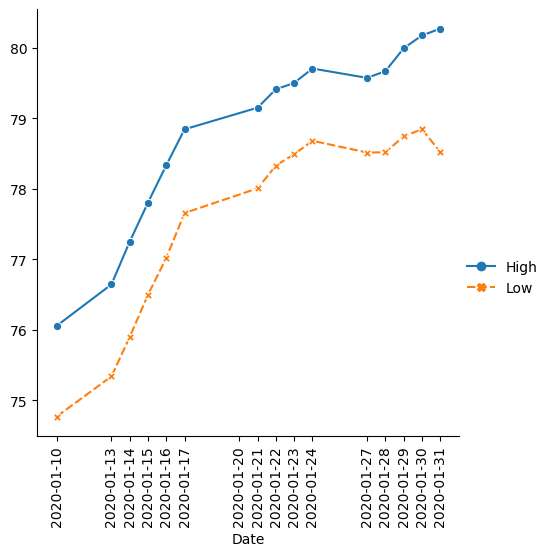

In [408]:
df = stockData[['High','Low']]. \
    query('Date <= "01/31/2020"').rolling(window=7, min_periods=7).mean()

g = sns.relplot(data=df, kind='line', markers=True)
for ax in g.axes.flat:
    ax.tick_params('x', labelrotation=90)
    ax.set_xticks(pd.date_range(start='01/10/2020', end='01/31/2020',
        freq='B'))
    ax.set_xticklabels(pd.date_range(start='01/10/2020', end='01/31/2020',
        freq='B').strftime('%Y-%m-%d'))

## How to create running totals (Forest Fire Data)
### Another way to smooth out data
- Also known as a cumulative sum
- You can look for rate of change, for example
- expanding: Creates a running aggregation for the Data Frame
- min_periods: Minimum number of observations to have a value
-  The expanding() method iterates through the DataFrame and applies the aggregate method up to and including the current row or column.- When the expanding() method is used with the sum() method, it generates running totals for the DataFrame.

In [409]:
acresBurned = pd.read_pickle('../data/acresBurned.pkl')
acresBurned.head()

,acres_burned
discovery_date,
1992-01-01,1280.76
1992-01-02,122.50
1992-01-03,526.00
1992-01-04,1150.13
1992-01-05,408.00


In [410]:
acresBurned['running_total'] = acresBurned.expanding().sum()
acresBurned.head()

,acres_burned,running_total
discovery_date,,
1992-01-01,1280.76,1280.76
1992-01-02,122.50,1403.26
1992-01-03,526.00,1929.26
1992-01-04,1150.13,3079.39
1992-01-05,408.00,3487.39


## How to plot the running totals

In [411]:
# get the first 10 days
acresBurned = acresBurned.head(10)

In [412]:
acresBurned = acresBurned.reset_index()
acresBurned.head(3)

,discovery_date,acres_burned,running_total
0,1992-01-01,1280.76,1280.76
1,1992-01-02,122.50,1403.26
2,1992-01-03,526.00,1929.26


#### This prepares the data to be used below
- This is necessary for plotting the data on the same plot
- If you expand this out, you will see that the data is "melted" meaning that for each day, there is a line for acres_burned and a line for running_total.
- This is necessary for plotting since we plot an x and a y so there can be only two values in each row that we plot. 

In [413]:
acresMelted = pd.melt(acresBurned, id_vars='discovery_date', 
              value_vars=['acres_burned','running_total'], var_name='value_type')
acresMelted.head(5)

,discovery_date,value_type,value
0,1992-01-01,acres_burned,1280.76
1,1992-01-02,acres_burned,122.50
2,1992-01-03,acres_burned,526.00
3,1992-01-04,acres_burned,1150.13
4,1992-01-05,acres_burned,408.00


In [414]:
acresMelted.tail(5)

,discovery_date,value_type,value
15,1992-01-06,running_total,4146.33
16,1992-01-07,running_total,4735.83
17,1992-01-08,running_total,5175.04
18,1992-01-09,running_total,5446.56
19,1992-01-10,running_total,6939.71


#### Plot the melted data (previous step)
- Plot both the acres burned each day and the running total for the first 10 days of the year.
- The plot is a bar plot, and the hue parameter is used to distinguish the daily total from the running total. 
- This plot makes it easy to see how the running total builds over time and how each day contributes to that total.

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


ConversionError: Failed to convert value(s) to axis units: 0    1992-01-01
1    1992-01-02
2    1992-01-03
3    1992-01-04
4    1992-01-05
5    1992-01-06
6    1992-01-07
7    1992-01-08
8    1992-01-09
9    1992-01-10
Name: discovery_date, dtype: object

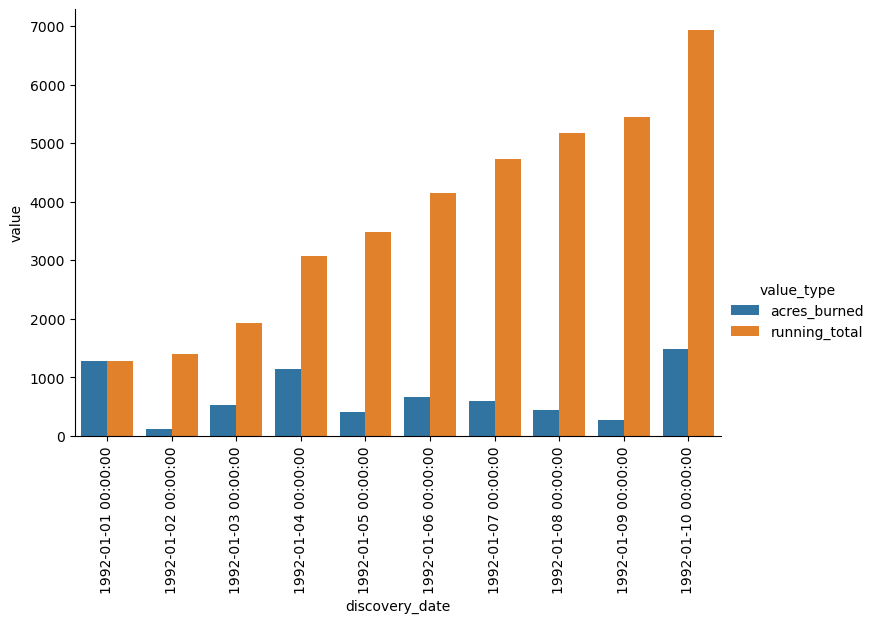

In [415]:
g = sns.catplot(data=acresMelted, kind='bar', 
                x='discovery_date', y='value', hue='value_type', aspect=1.5)
for ax in g.axes.flat:
    ax.tick_params('x', labelrotation=90)
    ax.set_xticks(acresMelted.discovery_date.drop_duplicates().astype(str))
    ax.set_xticklabels(acresMelted.discovery_date.drop_duplicates().astype(str))